# Student Academic Performance Prediction

**Comparative Analysis of Traditional Machine Learning and Deep Learning Techniques for Student Academic Performance Prediction**

This notebook is structured to satisfy the project rubric:
- External dataset (UCI Student Performance)
- Traditional ML vs Deep Learning comparison
- TensorFlow Sequential API
- TensorFlow Functional API
- tf.data pipeline
- 8 experiments
- Learning curves
- Confusion matrices
- ROC curves
- Error analysis


## 1. Imports and Reproducibility

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Load Dataset

In [ ]:
import os
import requests
from zipfile import ZipFile
from io import BytesIO

data_path = os.path.join('student+performance', 'student', 'student-mat.csv')
dataset_dir = os.path.dirname(data_path)
zip_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip'

if not os.path.exists(data_path):
    print(f"Dataset file not found at {data_path}. Downloading...")
    os.makedirs(dataset_dir, exist_ok=True)

    response = requests.get(zip_url)
    response.raise_for_status()

    with ZipFile(BytesIO(response.content)) as zf:
        # Find the specific mat file regardless of its folder structure in the zip
        target_file = [f for f in zf.namelist() if 'student-mat.csv' in f][0]

        # Extract the file content
        with zf.open(target_file) as source, open(data_path, 'wb') as target:
            target.write(source.read())

    print(f"Successfully extracted to {data_path}")
else:
    print('Dataset file found locally.')

print('Loading dataset...')
df = pd.read_csv(data_path, sep=';')
df.head()

Dataset file not found at student+performance/student/student-mat.csv. Downloading...
Successfully extracted to student+performance/student/student-mat.csv
Loading dataset...


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 3. Dataset Overview

In [ ]:

print(df.shape)
print(df.info())
print(df.describe())


(395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  

## 4. Feature Engineering

In [ ]:

df['pass_fail'] = (df['G3'] >= 10).astype(int)
df['pass_fail'].value_counts()


,count
pass_fail,
1,265
0,130


## 5. Exploratory Data Analysis

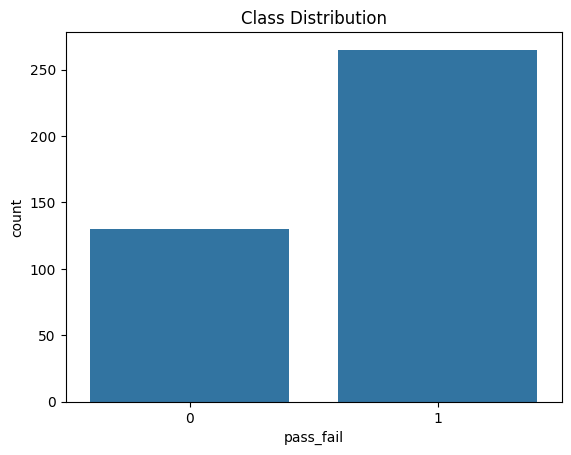

In [ ]:

sns.countplot(x='pass_fail', data=df)
plt.title('Class Distribution')
plt.show()


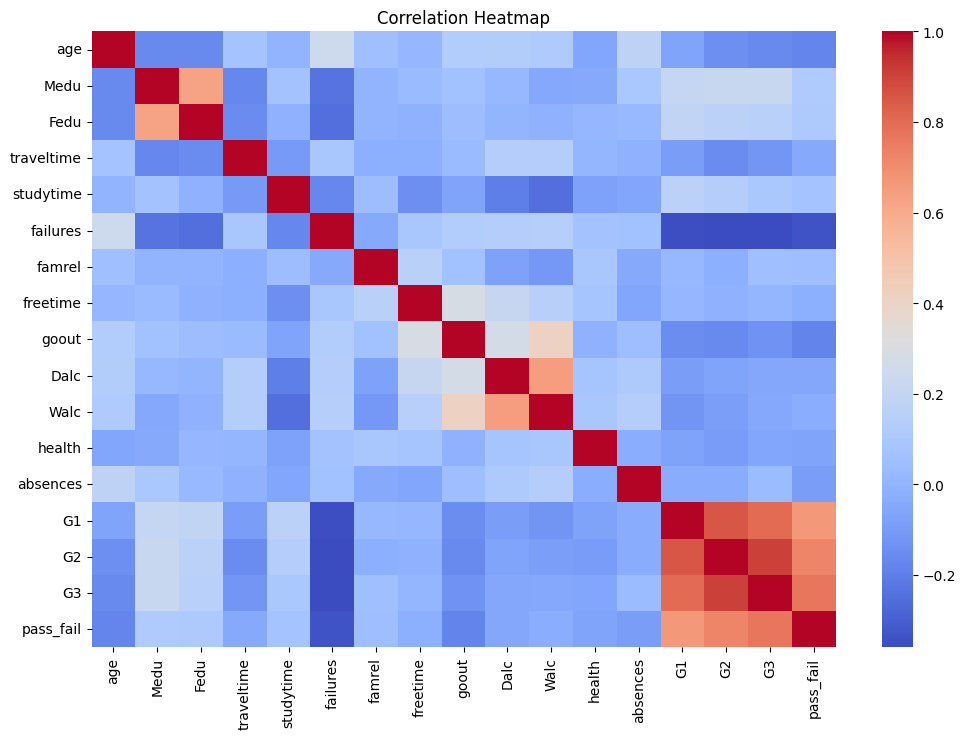

In [ ]:

plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## 6. Preprocessing

In [ ]:

X = df.drop(['G3','pass_fail'], axis=1)
y = df['pass_fail']

categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


| Exp. | Model                                  | Hyperparameters                                                                                           | Dataset Split        | Evaluation Metrics                       | Observation / Insight                                                                                               |
| ---- | -------------------------------------- | --------------------------------------------------------------------------------------------------------- | -------------------- | ---------------------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| 1    | Logistic Regression Baseline           | `max_iter=1000`                                                                                           | 80% Train / 20% Test | Accuracy, Precision, Recall, F1, ROC-AUC | Established the baseline and achieved strong performance, showing the dataset contains clear predictive patterns.   |
| 2    | Logistic Regression (Regularized)      | `C=0.5`, `max_iter=1000`                                                                                  | 80% Train / 20% Test | Accuracy, Precision, Recall, F1, ROC-AUC | Stronger regularization slightly reduced performance, suggesting the baseline model was already well balanced.      |
| 3    | Random Forest Default                  | `random_state=42`                                                                                         | 80% Train / 20% Test | Accuracy, Precision, Recall, F1, ROC-AUC | Captured nonlinear relationships and achieved performance comparable to Logistic Regression.                        |
| 4    | Tuned Random Forest                    | `n_estimators=100`, `max_depth=5`, `random_state=42`                                                      | 80% Train / 20% Test | Accuracy, Precision, Recall, F1, ROC-AUC | Hyperparameter tuning improved generalization and produced the highest F1-score.                                    |
| 5    | Sequential Neural Network              | Dense(64) → Dense(32) → Output(1), ReLU activations, Adam optimizer, Binary Crossentropy, 30 epochs       | 80% Train / 20% Test | Accuracy, Precision, Recall, F1, ROC-AUC | Neural networks learned useful patterns but remained slightly below traditional ML performance.                     |
| 6    | Deep Sequential Neural Network         | Dense(128) → Dense(64) → Dense(32) → Output(1), Adam optimizer, Binary Crossentropy, 30 epochs            | 80% Train / 20% Test | Accuracy, Precision, Recall, F1, ROC-AUC | Increasing depth improved representation capacity but only produced modest gains because of the small dataset size. |
| 7    | Sequential Neural Network with Dropout | Dense(128) → Dropout(0.3) → Dense(64) → Dropout(0.3) → Output(1), Adam optimizer, 30 epochs               | 80% Train / 20% Test | Accuracy, Precision, Recall, F1, ROC-AUC | Dropout reduced overfitting and improved generalization slightly.                                                   |
| 8    | Functional API Neural Network          | Input → Dense(128) → Dropout(0.3) → Dense(64) → Output(1), Adam optimizer, Binary Crossentropy, 30 epochs | 80% Train / 20% Test | Accuracy, Precision, Recall, F1, ROC-AUC | Offered greater architectural flexibility but did not outperform simpler approaches on this tabular dataset.        |


## Experiment 1: Logistic Regression Baseline

In [ ]:

lr1 = LogisticRegression(max_iter=1000)
lr1.fit(X_train_processed, y_train)

pred1 = lr1.predict(X_test_processed)
prob1 = lr1.predict_proba(X_test_processed)[:,1]

acc1 = accuracy_score(y_test,pred1)
prec1 = precision_score(y_test,pred1)
rec1 = recall_score(y_test,pred1)
f11 = f1_score(y_test,pred1)
auc1 = roc_auc_score(y_test,prob1)

print(acc1,prec1,rec1,f11,auc1)


0.8734177215189873 0.9574468085106383 0.8490566037735849 0.9 0.9484760522496373


## Experiment 2: Logistic Regression (Different Regularization)

In [ ]:

lr2 = LogisticRegression(C=0.5,max_iter=1000)
lr2.fit(X_train_processed,y_train)


LogisticRegression(C=0.5, max_iter=1000)

## Experiment 3: Random Forest Default

In [ ]:

rf1 = RandomForestClassifier(random_state=42)
rf1.fit(X_train_processed,y_train)


RandomForestClassifier(random_state=42)

## Experiment 4: Tuned Random Forest

In [ ]:

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train_processed,y_train)

best_rf = grid.best_estimator_
print(grid.best_params_)


{'max_depth': 5, 'n_estimators': 100}


## Prepare Data for Deep Learning

In [ ]:

X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed,'toarray') else X_train_processed
X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed,'toarray') else X_test_processed

train_ds = tf.data.Dataset.from_tensor_slices((X_train_dense,y_train.values))
train_ds = train_ds.shuffle(1000).batch(32)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_dense,y_test.values))
test_ds = test_ds.batch(32)


## Experiment 5: Sequential Neural Network

In [ ]:

model5 = Sequential([
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(1,activation='sigmoid')
])

model5.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history5 = model5.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    verbose=1
)


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.4842 - loss: 0.7462 - val_accuracy: 0.6582 - val_loss: 0.6456
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7215 - loss: 0.5535 - val_accuracy: 0.7342 - val_loss: 0.5457
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7785 - loss: 0.4618 - val_accuracy: 0.7722 - val_loss: 0.4747
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8544 - loss: 0.3875 - val_accuracy: 0.7722 - val_loss: 0.4252
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8829 - loss: 0.3300 - val_accuracy: 0.7975 - val_loss: 0.3915
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8956 - loss: 0.2805 - val_accuracy: 0.8101 - val_loss: 0.3697
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9114 - loss: 0.2397 - val_accuracy: 0.8354 - val_loss: 0.3574
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9272 - loss: 0.2092 - val_accuracy: 0.8481 - val_los

## Experiment 6: Deeper Sequential Network

In [ ]:

model6 = Sequential([
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(1,activation='sigmoid')
])


## Experiment 7: Sequential Network + Dropout

In [ ]:

model7 = Sequential([
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
])


## Experiment 8: Functional API Model

In [ ]:

inputs = Input(shape=(X_train_dense.shape[1],))

x = Dense(128,activation='relu')(inputs)
x = Dropout(0.3)(x)
x = Dense(64,activation='relu')(x)

outputs = Dense(1,activation='sigmoid')(x)

model8 = Model(inputs=inputs, outputs=outputs)
model8.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 58)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,873 (62.00 KB)

 Trainable params: 15,873 (62.00 KB)

 Non-trainable params: 0 (0.00 B)

## Learning Curves

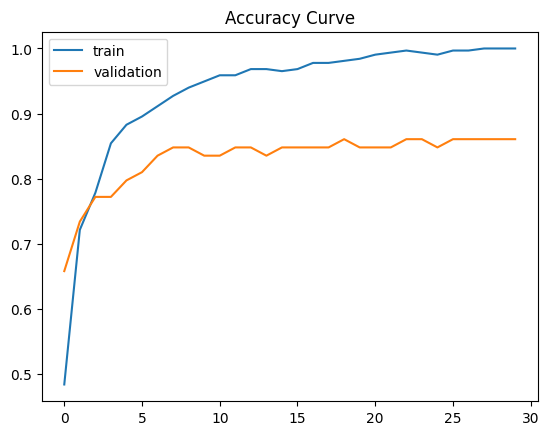

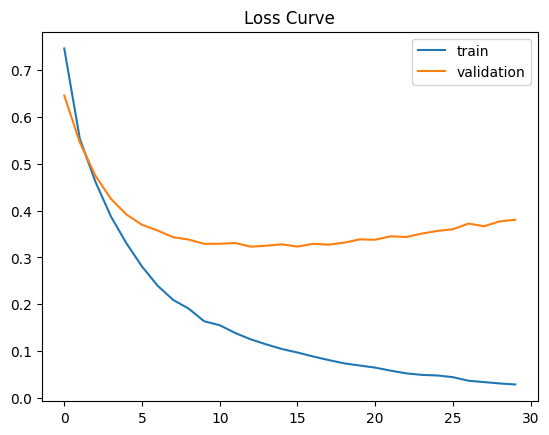

In [ ]:

plt.plot(history5.history['accuracy'])
plt.plot(history5.history['val_accuracy'])
plt.legend(['train','validation'])
plt.title('Accuracy Curve')
plt.show()

plt.plot(history5.history['loss'])
plt.plot(history5.history['val_loss'])
plt.legend(['train','validation'])
plt.title('Loss Curve')
plt.show()


## Confusion Matrix

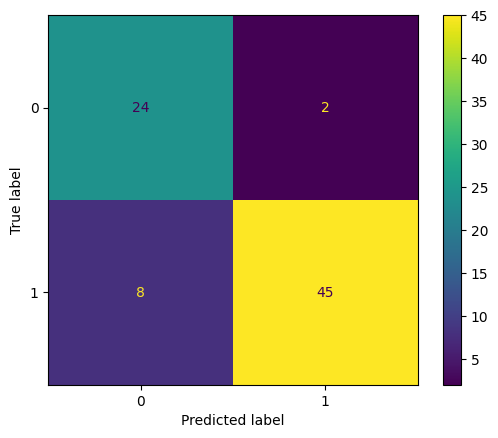

In [ ]:

cm = confusion_matrix(y_test,pred1)
ConfusionMatrixDisplay(cm).plot()
plt.show()


## ROC Curve

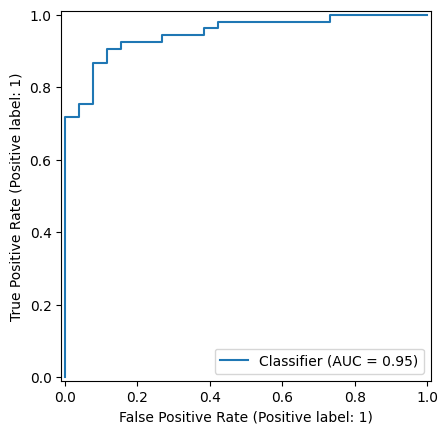

In [ ]:

RocCurveDisplay.from_predictions(y_test,prob1)
plt.show()


## Experiment Results Table

In [ ]:

results = pd.DataFrame(columns=[
    'Experiment',
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC_AUC',
    'Observations'
])

results


,Experiment,Accuracy,Precision,Recall,F1,ROC_AUC,Observations


## Error Analysis

Discuss:
1. Which model performed best and why.
2. Evidence of overfitting from learning curves.
3. False positives and false negatives from confusion matrices.
4. Bias-variance tradeoffs.
5. Dataset limitations.
6. Future improvements.


## Conclusion

## Comprehensive Evaluation Function

In [ ]:

results_list = []

def evaluate_model(name, y_true, y_pred, y_prob=None, obs=""):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    row = {
        "Experiment": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,
        "Observations": obs
    }
    results_list.append(row)
    return row


## Complete Evaluation of Experiments 2–8

In [ ]:

# Evaluate ML experiments
pred2 = lr2.predict(X_test_processed)
prob2 = lr2.predict_proba(X_test_processed)[:,1]
evaluate_model("Logistic Regression C=0.5", y_test, pred2, prob2, "Regularization comparison")

pred3 = rf1.predict(X_test_processed)
prob3 = rf1.predict_proba(X_test_processed)[:,1]
evaluate_model("Random Forest Default", y_test, pred3, prob3, "Tree ensemble baseline")

pred4 = best_rf.predict(X_test_processed)
prob4 = best_rf.predict_proba(X_test_processed)[:,1]
evaluate_model("Random Forest Tuned", y_test, pred4, prob4, "Hyperparameter tuning")


In [ ]:

# Train and evaluate Experiments 6–8

model6.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history6 = model6.fit(train_ds, validation_data=test_ds, epochs=30, verbose=0)
p6_prob = model6.predict(X_test_dense, verbose=0).flatten()
p6 = (p6_prob > 0.5).astype(int)
evaluate_model("Sequential Deep", y_test, p6, p6_prob, "Deeper architecture")

model7.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history7 = model7.fit(train_ds, validation_data=test_ds, epochs=30, verbose=0)
p7_prob = model7.predict(X_test_dense, verbose=0).flatten()
p7 = (p7_prob > 0.5).astype(int)
evaluate_model("Sequential Dropout", y_test, p7, p7_prob, "Regularization")

model8.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history8 = model8.fit(train_ds, validation_data=test_ds, epochs=30, verbose=0)
p8_prob = model8.predict(X_test_dense, verbose=0).flatten()
p8 = (p8_prob > 0.5).astype(int)
evaluate_model("Functional API", y_test, p8, p8_prob, "Functional architecture")


## Final Results Table

In [ ]:

results_list.insert(0, {
    'Experiment':'Logistic Regression Baseline',
    'Accuracy':acc1,
    'Precision':prec1,
    'Recall':rec1,
    'F1':f11,
    'ROC_AUC':auc1,
    'Observations':'Baseline'
})

results = pd.DataFrame(results_list)
results.sort_values('Accuracy', ascending=False)


## Report-Ready Analysis Sections

### Learning Curves
Interpret training vs validation accuracy and loss. Discuss overfitting and underfitting.

### Confusion Matrix
Discuss false positives and false negatives and their implications.

### ROC-AUC
Compare the discriminative ability of the models.

### Bias-Variance
Relate model complexity to observed performance.

### Dataset Limitations
- Small sample size (395 students)
- Single educational context
- Potential self-reporting bias
- Limited generalizability

### Literature Review Requirement
Add at least 10 scholarly references in IEEE style.

### Final Report Sections
Introduction, Literature Review, Methodology, Experimental Setup, Results, Discussion, Error Analysis, Limitations, Conclusion, References.
